In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_squared_log_error,
    median_absolute_error,
    explained_variance_score
)

## Applications per Ad - Regression

In [2]:
df = pd.read_excel('AU_PUBLISHED_DATASET 01-08-2026.xlsx', sheet_name='SEEK Applications per Ad Index')
df

,DATE,COUNTRY,STATE,CA_SA_INDEX,CA_TREND_INDEX,CA_SA_GROWTH_MONTH,CA_SA_GROWTH_PCP,CA_TREND_GROWTH_MONTH,CA_TREND_GROWTH_PCP
0,2008-02-01,Australia,Total,19.45,26.62,0.000000,0.000000,0.000000,0.000000
1,2008-03-01,Australia,Total,27.33,27.50,0.404762,0.000000,0.032967,0.000000
2,2008-04-01,Australia,Total,30.18,28.72,0.104371,0.000000,0.044326,0.000000
3,2008-05-01,Australia,Total,30.16,30.20,-0.000808,0.000000,0.051783,0.000000
4,2008-06-01,Australia,Total,31.25,31.91,0.036378,0.000000,0.056497,0.000000
...,...,...,...,...,...,...,...,...,...
1993,2026-03-01,Australia,WA,137.08,137.89,0.002249,-0.054961,0.008018,-0.036812
1994,2026-04-01,Australia,WA,150.35,139.34,0.096799,0.051253,0.010476,-0.034748
1995,2026-05-01,Australia,WA,144.98,140.61,-0.035676,-0.020513,0.009120,-0.033379
1996,2026-06-01,Australia,WA,141.12,141.53,-0.026663,-0.008272,0.006564,-0.032019


In [3]:
df['STATE'].value_counts()

STATE
Total    222
ACT      222
NSW      222
NT       222
QLD      222
SA       222
TAS      222
VIC      222
WA       222
Name: count, dtype: int64

In [15]:
len(df)

1998

### Clean Dataset

In [4]:
applications = df.dropna()

In [5]:
len(applications)

1989

In [6]:
applications.dtypes

DATE                     datetime64[ns]
COUNTRY                          object
STATE                            object
CA_SA_INDEX                     float64
CA_TREND_INDEX                  float64
CA_SA_GROWTH_MONTH              float64
CA_SA_GROWTH_PCP                float64
CA_TREND_GROWTH_MONTH           float64
CA_TREND_GROWTH_PCP             float64
dtype: object

### Decision Tree Regressor

In [32]:
X = applications.drop(columns=['CA_TREND_GROWTH_MONTH', 'DATE', 'COUNTRY', 'STATE'], axis=1)
y = applications['CA_TREND_GROWTH_MONTH']
testing_size = 0.2

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=testing_size, random_state=10)

In [41]:
def quick_summary(y_true, y_pred):
    print(f"R²:  {r2_score(y_true, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"MAPE: {np.mean(np.abs((y_true - y_pred) / y_true)) * 100:.2f}%")

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

def regression_visual_report(y_true, y_pred, title="Regression Performance"):
    """
    Create visual report with plots
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(title, fontsize=16)
    
    # 1. Actual vs Predicted
    axes[0, 0].scatter(y_true, y_pred, alpha=0.6)
    axes[0, 0].plot([y_true.min(), y_true.max()], 
                    [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0, 0].set_xlabel('Actual')
    axes[0, 0].set_ylabel('Predicted')
    axes[0, 0].set_title(f'Actual vs Predicted (R²={r2_score(y_true, y_pred):.3f})')
    
    # 2. Residuals plot
    residuals = y_true - y_pred
    axes[0, 1].scatter(y_pred, residuals, alpha=0.6)
    axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Residuals')
    axes[0, 1].set_title('Residual Plot')
    
    # 3. Distribution of errors
    axes[0, 2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    axes[0, 2].axvline(x=0, color='r', linestyle='--', lw=2)
    axes[0, 2].set_xlabel('Residuals')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].set_title('Error Distribution')
    
    # 4. Q-Q plot
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('Q-Q Plot')
    
    # 6. Metrics summary
    metrics_text = f"""
    R²:  {r2_score(y_true, y_pred):.4f}
    RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}
    MAE:  {mean_absolute_error(y_true, y_pred):.4f}
    MAPE: {np.mean(np.abs((y_true - y_pred) / y_true)) * 100:.2f}%
    """
    axes[1, 2].text(0.1, 0.5, metrics_text, fontsize=14, 
                    verticalalignment='center',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1, 2].set_axis_off()
    axes[1, 2].set_title('Performance Summary')
    
    plt.tight_layout()
    plt.show()


R²:  0.4997
RMSE: 0.0219
MAE:  0.0161
MAPE: inf%


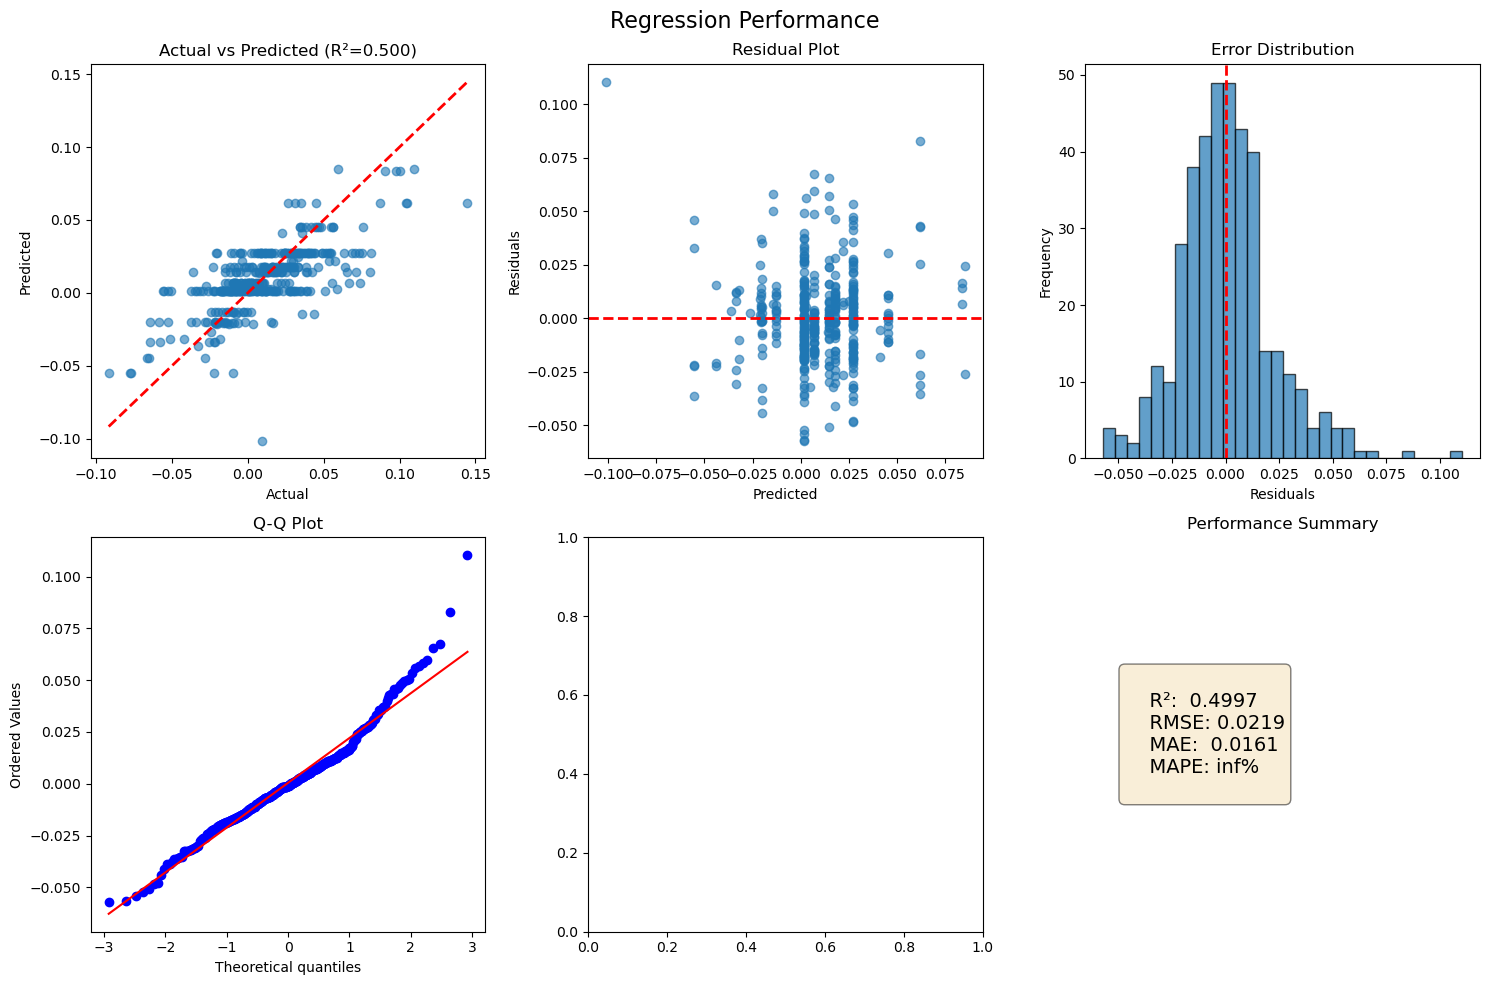

In [49]:
d_tree = DecisionTreeRegressor(max_depth=5)
tree_fit = d_tree.fit(X_train, y_train)
y_pre = tree_fit.predict(X_test)
# cm = confusion_matrix(y_test, y_pre)
# cm

quick_summary(y_test, y_pre)

regression_visual_report(y_test, y_pre)

### Other regression model

In [ ]:
# with MAE, MSE, RMSE and R2 score as error measure

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

## Advertised Salary Dataset - Regression

### Obtaining and Cleaning Dataset

In [12]:
data = pd.read_excel('seek_asi.xlsx')
data

,date,COUNTRY,STATE,CLASSIFICATION,SALARY_SA_INDEX,SALARY_SA_GROWTH_MONTH,SALARY_SA_GROWTH_PCP,SALARY_TREND_INDEX,SALARY_TREND_GROWTH_MONTH,SALARY_TREND_GROWTH_PCP
0,2016-01-01,Australia,Total,Total,92.269113,NaN,NaN,92.564560,NaN,NaN
1,2016-02-01,Australia,Total,Total,92.564113,0.003197,NaN,92.685597,0.001308,NaN
2,2016-03-01,Australia,Total,Total,92.894614,0.003571,NaN,92.834295,0.001604,NaN
3,2016-04-01,Australia,Total,Total,93.199239,0.003279,NaN,92.996739,0.001750,NaN
4,2016-05-01,Australia,Total,Total,93.172053,-0.000292,NaN,93.164307,0.001802,NaN
...,...,...,...,...,...,...,...,...,...,...
4531,2026-06-01,Australia,Total,Retail & Consumer Products,123.577227,0.005261,0.040757,123.323461,0.003093,0.037744
4532,2026-06-01,Australia,Total,Sales,120.547615,-0.000104,0.027925,120.605488,0.000578,0.028847
4533,2026-06-01,Australia,Total,Science & Technology,114.334770,0.006635,0.035074,114.208698,0.003502,0.032735
4534,2026-06-01,Australia,Total,Sport & Recreation,125.633585,-0.002099,0.058329,125.297324,0.003717,0.053668


In [14]:
salary_data = data.dropna()
len(salary_data)

4104

In [25]:
salary_data.dtypes

date                         datetime64[ns]
COUNTRY                              object
STATE                                object
CLASSIFICATION                       object
SALARY_SA_INDEX                     float64
SALARY_SA_GROWTH_MONTH              float64
SALARY_SA_GROWTH_PCP                float64
SALARY_TREND_INDEX                  float64
SALARY_TREND_GROWTH_MONTH           float64
SALARY_TREND_GROWTH_PCP             float64
dtype: object

In [87]:
salary_data['STATE'].value_counts()

STATE
Total    3192
ACT       114
NSW       114
NT        114
QLD       114
SA        114
TAS       114
VIC       114
WA        114
Name: count, dtype: int64

## Clustering Models

### K-Means Clustering - SEEK Applications Dataset

find the states with the highest job application rates

In [90]:
applications

,DATE,COUNTRY,STATE,CA_SA_INDEX,CA_TREND_INDEX,CA_SA_GROWTH_MONTH,CA_SA_GROWTH_PCP,CA_TREND_GROWTH_MONTH,CA_TREND_GROWTH_PCP
0,2008-02-01,Australia,Total,19.45,26.62,0.000000,0.000000,0.000000,0.000000
1,2008-03-01,Australia,Total,27.33,27.50,0.404762,0.000000,0.032967,0.000000
2,2008-04-01,Australia,Total,30.18,28.72,0.104371,0.000000,0.044326,0.000000
3,2008-05-01,Australia,Total,30.16,30.20,-0.000808,0.000000,0.051783,0.000000
4,2008-06-01,Australia,Total,31.25,31.91,0.036378,0.000000,0.056497,0.000000
...,...,...,...,...,...,...,...,...,...
1992,2026-02-01,Australia,WA,136.77,136.80,0.029190,-0.017488,0.000979,-0.035916
1993,2026-03-01,Australia,WA,137.08,137.89,0.002249,-0.054961,0.008018,-0.036812
1994,2026-04-01,Australia,WA,150.35,139.34,0.096799,0.051253,0.010476,-0.034748
1995,2026-05-01,Australia,WA,144.98,140.61,-0.035676,-0.020513,0.009120,-0.033379


In [91]:
applications.dtypes

DATE                     datetime64[ns]
COUNTRY                          object
STATE                            object
CA_SA_INDEX                     float64
CA_TREND_INDEX                  float64
CA_SA_GROWTH_MONTH              float64
CA_SA_GROWTH_PCP                float64
CA_TREND_GROWTH_MONTH           float64
CA_TREND_GROWTH_PCP             float64
dtype: object

In [67]:
applications['STATE'].value_counts()

STATE
Total    221
ACT      221
NSW      221
NT       221
QLD      221
SA       221
TAS      221
VIC      221
WA       221
Name: count, dtype: int64

#### Feature Engineering

In [96]:
# calculate mean of CSA index values from 2016-2026 for each state

states = applications['STATE'].unique().tolist()
mean_CA_index = []

for state in states:
    if (state != 'Total'):
        mask = (applications['STATE'] == state) & (applications['DATE'].dt.year.between(2016, 2026))
        mean_CA_index.append(applications.loc[mask, 'CA_SA_INDEX'].mean())

mean_CA_index

[np.float64(174.5101587301587),
 np.float64(166.44119047619046),
 np.float64(116.93992063492063),
 np.float64(102.78452380952382),
 np.float64(94.67309523809521),
 np.float64(125.6607142857143),
 np.float64(145.99103174603172),
 np.float64(92.51142857142858)]

In [101]:
SA_index_volatility = []

for state in states:
    if (state != 'Total'):
        mask = (applications['STATE'] == state) & (applications['DATE'].dt.year.between(2016, 2026))
        SA_index_volatility.append(applications.loc[mask, 'CA_SA_INDEX'].std())

SA_index_volatility

[91.55205872056948,
 78.37083782741786,
 36.33884364689734,
 25.634785448125527,
 20.580319510222793,
 26.53094996199183,
 74.47640008302619,
 30.214520183892663]

In [106]:
yoy_SA_growth_volatility = []

for state in states:
    if (state != 'Total'):
        mask = (applications['STATE'] == state) & (applications['DATE'].dt.year.between(2016, 2026))
        yoy_SA_growth_volatility.append(applications.loc[mask, 'CA_SA_GROWTH_PCP'].std())

yoy_SA_growth_volatility

[0.2535776748539814,
 0.4055302195991088,
 0.25786493756324774,
 0.28931780986780437,
 0.2454347695516272,
 0.20204297421158215,
 0.45266215730207554,
 0.326557121903261]

In [107]:
mom_SA_growth_volatility = []

for state in states:
    if (state != 'Total'):
        mask = (applications['STATE'] == state) & (applications['DATE'].dt.year.between(2016, 2026))
        mom_SA_growth_volatility.append(applications.loc[mask, 'CA_SA_GROWTH_MONTH'].std())

mom_SA_growth_volatility

[0.05823285017210704,
 0.06265756500021788,
 0.062227944223361406,
 0.052092313201750735,
 0.06142077197453924,
 0.059181580276517334,
 0.07443687915961919,
 0.04771765092430511]

In [113]:
feature_matrix = pd.DataFrame()
feature_matrix['MEAN_SA_INDEX'] = mean_CA_index
feature_matrix['SA_INDEX_VOLATILITY'] = SA_index_volatility
feature_matrix['YOY_SA_GROWTH_VOLATILITY'] = yoy_SA_growth_volatility
feature_matrix['MOM_SA_GROWTH_VOLATILITY'] = mom_SA_growth_volatility

feature_matrix

,MEAN_SA_INDEX,SA_INDEX_VOLATILITY,YOY_SA_GROWTH_VOLATILITY,MOM_SA_GROWTH_VOLATILITY
0,174.510159,91.552059,0.253578,0.058233
1,166.441190,78.370838,0.405530,0.062658
2,116.939921,36.338844,0.257865,0.062228
3,102.784524,25.634785,0.289318,0.052092
4,94.673095,20.580320,0.245435,0.061421
5,125.660714,26.530950,0.202043,0.059182
6,145.991032,74.476400,0.452662,0.074437
7,92.511429,30.214520,0.326557,0.047718
